In [3]:
#Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pywt

In [4]:
#Funciones auxiliares
def leer_archivo_txt(nombre_archivo, saltar_lineas=5, delimitador=';'):
    try:
        df = pd.read_csv(nombre_archivo, delimiter=delimitador, skiprows=saltar_lineas)
        df.columns = df.columns.str.strip()
        df['Wave'] = pd.to_numeric(df['Wave'], errors='coerce')
        df['Scope Corrected for Dark'] = pd.to_numeric(df['Scope Corrected for Dark'], errors='coerce')
        df.dropna(inplace=True)
        return df
    except Exception as e:
        print(f"Error al leer el archivo: {e}")
        return None


In [76]:
#Leer archivos

UV1 = "2.E2E_olivine/Olivine_LIBS_shot01_7324767SP.txt" 
UV2 = "2.E2E_olivine/Olivine_LIBS_shot01_7324768SP.txt" 
VIS = "2.E2E_olivine/Olivine_LIBS_shot01_7324769SP.txt" 
NIR = "2.E2E_olivine/Olivine_LIBS_shot01_7324770SP.txt" 

datos_UV1 = leer_archivo_txt(UV1)
datos_UV2 = leer_archivo_txt(UV2)
datos_VIS = leer_archivo_txt(VIS)
datos_NIR = leer_archivo_txt(NIR)

espectro_UV1 = datos_UV1['Scope Corrected for Dark'].values
wavelength = datos_UV1['Wave'].values

In [100]:
#Simulamos el Undecimated Wavelet Transform (UWT)
#usamos la función pywt.swt(signal, wavelet, level) que realiza la transformada wavelet estacionaria
#signal: nuestro espectro
#wavelet: para aproximarse a B_3-spline de SuperCam crearemos nuestro propio wavelet
#level: número de niveles de descomposición


#Creamos nuestro wavelet siguiendo los filtros de super cam
#Low pass filter h(z) = 1/16(z^-2 + 4z^-1 + 6 + 4z + z^2)
h = [0,0,0,1,4,6,4,1,0,0]
h = [x/16 for x in h]

#High pass filter g(z) = 1/256(-z^-4 -8z^-3 - 28z^-2 -56z^-1 +186 -56z - 28z^2 - 8z^3 - z^4)
g = [0,-1,-8,-28,-56,186,-56,-28,-8,-1]
g = [x/256 for x in g]

#Armar el banco de filtros en el orden requerido
filter_bank = [h,g,h,g] #UWT usa mismos filtros para análisis y síntesis

#Creamos el wavelet personalizado
supercam_wavelet = pywt.Wavelet(name="supercam", filter_bank=filter_bank)

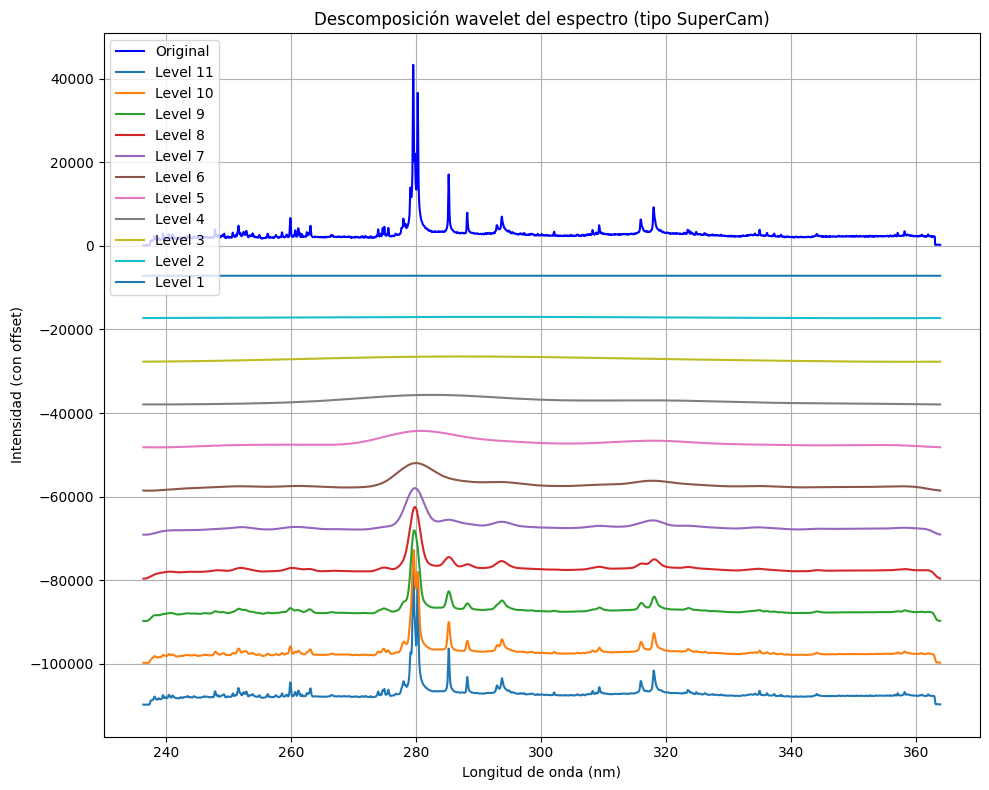

In [120]:
# Reaplicar el nivel correcto
level = 11
coeffs = pywt.swt(espectro_UV1, supercam_wavelet, level=level)

# Gráfico tipo SuperCam con offset vertical por escala
plt.figure(figsize=(10, 8))

# Espectro original
plt.plot(wavelength, espectro_UV1, label="Original", color='blue')

# Dibujamos cada escala con desplazamiento vertical
offset = 10000  # para separación entre escalas
for i, (cA, cD) in enumerate(reversed(coeffs)):
    level_num = level - i
    plt.plot(wavelength, cA - offset * level_num, label=f"Level {level_num}")

plt.title("Descomposición wavelet del espectro (tipo SuperCam)")
plt.xlabel("Longitud de onda (nm)")
plt.ylabel("Intensidad (con offset)")

plt.legend()
plt.grid(True)
plt.tight_layout()


In [121]:
#Ahora aplicaremos Sigma clipping (quitamos los valores de los coeficientes que estén por debajo de un umbral de 3sigmas)
#Esto elimina el ruido de los coeficientes

filtered_coeffs = []
for cA, cD in coeffs:
    sigma = np.std(np.abs(cD))
    threshold = 3 * sigma
    cD_filtered = np.where(np.abs(cD) < threshold, 0, cD)  # Elimina el ruido
    filtered_coeffs.append((cA, cD_filtered))

In [122]:
#Recosntuir el espectro
denoised_spectrum_UV1 = pywt.iswt(filtered_coeffs, supercam_wavelet)
spectrum_UV1 = pywt.iswt(coeffs, supercam_wavelet)


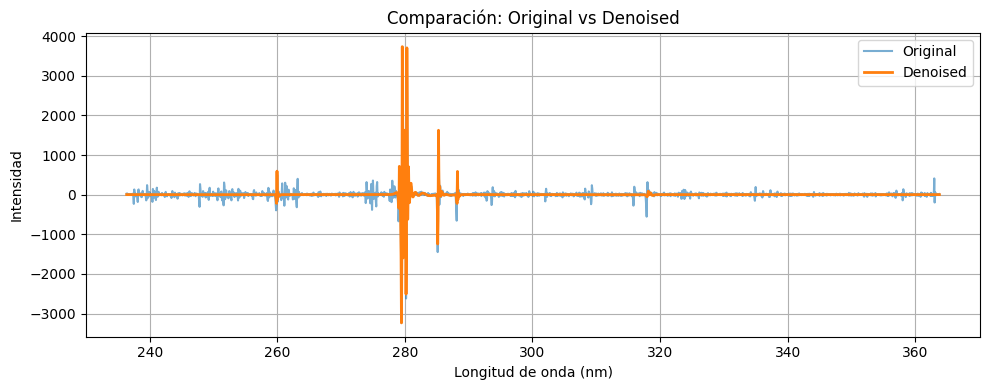

In [123]:
# Comparamos resultados

plt.figure(figsize=(10, 4))
plt.plot(wavelength, spectrum_UV1, label="Original", alpha=0.6)
plt.plot(wavelength, denoised_spectrum_UV1, label="Denoised", linewidth=2)
plt.title("Comparación: Original vs Denoised")
plt.xlabel("Longitud de onda (nm)")
plt.ylabel("Intensidad")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

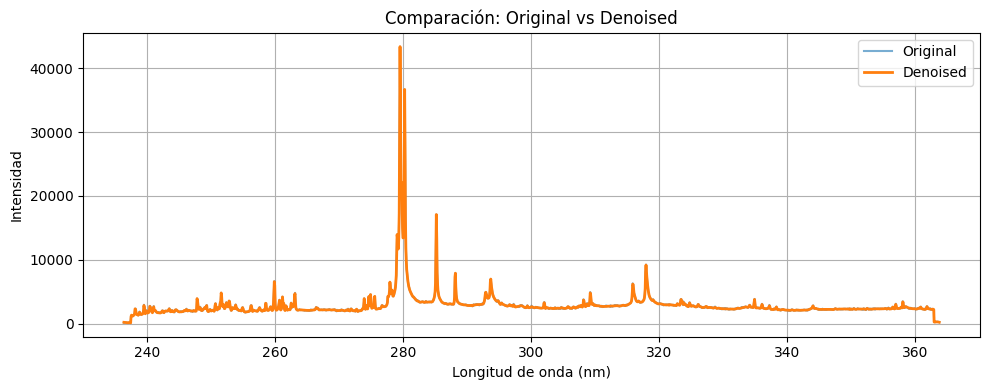

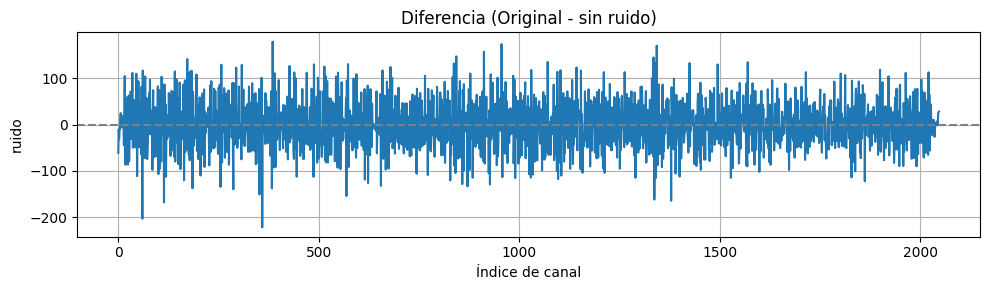

In [144]:
wavelet = pywt.Wavelet('bior3.3')

# Reaplicar el nivel correcto
level = 11
coeffs = pywt.swt(espectro_UV1, wavelet, level=level)

sigma = np.median(np.abs(coeffs[-1][1])) / 0.6745  # Estimación robusta de la desviación estándar
threshold = 4 * sigma

# Aplicamos el umbral a los coeficientes de detalle
filtered_coeffs = [(cA, pywt.threshold(cD, threshold, mode='hard')) for cA, cD in coeffs]

#Recosntuir el espectro
denoised_spectrum_UV1 = pywt.iswt(filtered_coeffs, wavelet)

# Comparamos resultados
plt.figure(figsize=(10, 4))
plt.plot(wavelength, espectro_UV1, label="Original", alpha=0.6)
plt.plot(wavelength, denoised_spectrum_UV1, label="Denoised", linewidth=2)
plt.title("Comparación: Original vs Denoised")
plt.xlabel("Longitud de onda (nm)")
plt.ylabel("Intensidad")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Ruido punto a punto
error = espectro_UV1 - denoised_spectrum_UV1
plt.figure(figsize=(10, 3))
plt.plot(error, label='Ruido quitado')
plt.axhline(0, color='gray', linestyle='--')
plt.title("Diferencia (Original - sin ruido)")
plt.xlabel("Índice de canal")
plt.ylabel("ruido")
plt.grid(True)
plt.tight_layout()
plt.show()

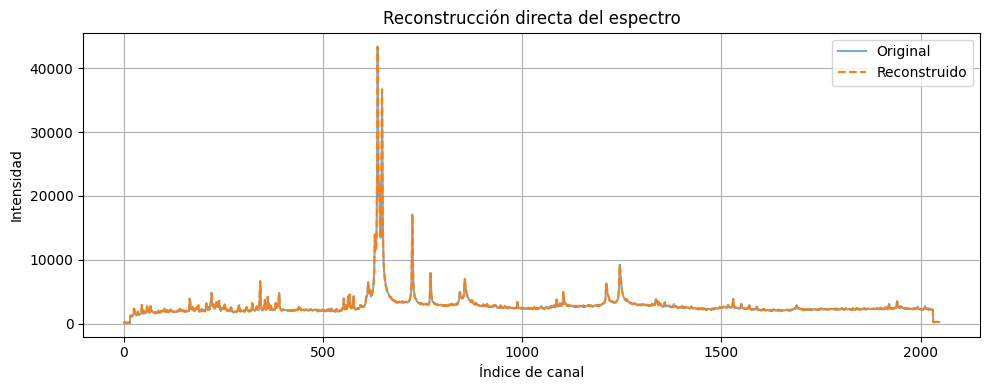

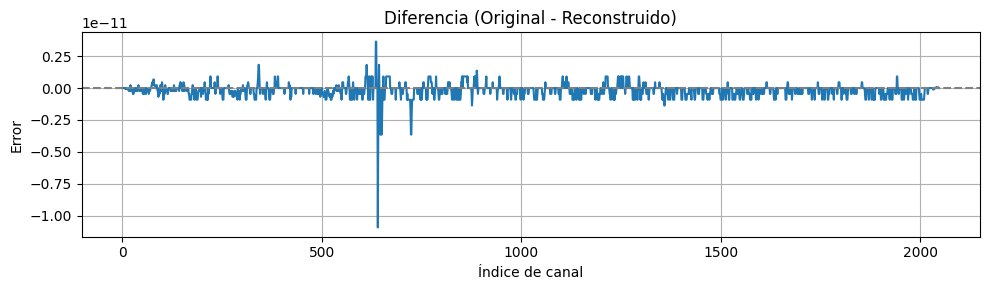

Error absoluto máximo: 1.0913936421275139e-11


In [136]:
import numpy as np
import matplotlib.pyplot as plt
import pywt

# Suponemos que ya tienes este array:
# espectro_UV1 = datos_UV1["Scope Corrected for Dark"].values

# Parámetros del wavelet y número de niveles
wavelet = pywt.Wavelet('bior3.3')  # Puedes cambiarlo luego al personalizado
#wavelet = supercam_wavelet  # Puedes cambiarlo luego al personalizado
#wavelet = custom_wavelet

level = 3  # Asegúrate de que 2**level divide la longitud

# Función para hacer padding hasta múltiplo de 2^level
def pad_to_multiple(x, base):
    remainder = len(x) % base
    if remainder == 0:
        return x, 0
    pad_size = base - remainder
    x_padded = np.pad(x, (0, pad_size), mode='edge')  # relleno por repetición del borde
    return x_padded, pad_size

# Preparamos el espectro
espectro_padded, pad_size = pad_to_multiple(espectro_UV1, 2**level)

# Transformada SWT
coeffs = pywt.swt(espectro_padded, wavelet, level=level)

# Reconstrucción directa
recon_padded = pywt.iswt(coeffs, wavelet)
recon = recon_padded[:len(espectro_UV1)]  # quitamos el padding

# Comparación visual
plt.figure(figsize=(10, 4))
plt.plot(espectro_UV1, label='Original', alpha=0.6)
plt.plot(recon, label='Reconstruido', linestyle='--')
plt.title("Reconstrucción directa del espectro")
plt.xlabel("Índice de canal")
plt.ylabel("Intensidad")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Error punto a punto
error = espectro_UV1 - recon
plt.figure(figsize=(10, 3))
plt.plot(error, label='Error')
plt.axhline(0, color='gray', linestyle='--')
plt.title("Diferencia (Original - Reconstruido)")
plt.xlabel("Índice de canal")
plt.ylabel("Error")
plt.grid(True)
plt.tight_layout()
plt.show()

# Error máximo
print("Error absoluto máximo:", np.max(np.abs(error)))
